In [361]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Load the Dataset

In [362]:
df = pd.read_csv("data/car_price_prediction.csv")
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [363]:
df.shape

(19237, 18)

### Check missing value

In [364]:
df.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [365]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [366]:
df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [367]:
df.describe(include='object')

,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color
count,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237
unique,559,65,1590,11,2,7,107,7687,4,3,3,2,16
top,-,HYUNDAI,Prius,Sedan,Yes,Petrol,2,0 km,Automatic,Front,04-May,Left wheel,Black
freq,5819,3769,1083,8736,13954,10150,3916,721,13514,12874,18332,17753,5033


### check - value how many total missing value

In [368]:
df['Levy'] = df['Levy'].replace({'-': np.nan})

In [369]:
df["Levy"].dtypes

<StringDtype(storage='python', na_value=nan)>

In [370]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(f"Length of {len(categorical_cols)} Categorical columns: {categorical_cols}")
print(f"Length of {len(numerical_cols)} Numerical columns: {numerical_cols}")

Length of 13 Categorical columns: Index(['Levy', 'Manufacturer', 'Model', 'Category', 'Leather interior',
       'Fuel type', 'Engine volume', 'Mileage', 'Gear box type',
       'Drive wheels', 'Doors', 'Wheel', 'Color'],
      dtype='str')
Length of 5 Numerical columns: Index(['ID', 'Price', 'Prod. year', 'Cylinders', 'Airbags'], dtype='str')


In [371]:
for col in categorical_cols:
    print(pd.DataFrame(df[col].value_counts().head(10)))

      count
Levy       
765     486
891     461
639     410
640     405
1017    298
781     297
707     270
642     265
836     260
779     252
               count
Manufacturer        
HYUNDAI         3769
TOYOTA          3662
MERCEDES-BENZ   2076
FORD            1111
CHEVROLET       1069
BMW             1049
LEXUS            982
HONDA            977
NISSAN           660
VOLKSWAGEN       579
          count
Model          
Prius      1083
Sonata     1079
Camry       938
Elantra     922
E 350       542
Santa FE    533
FIT         446
H1          437
Tucson      429
X5          353
             count
Category          
Sedan         8736
Jeep          5473
Hatchback     2847
Minivan        647
Coupe          532
Universal      364
Microbus       306
Goods wagon    233
Pickup          52
Cabriolet       36
                  count
Leather interior       
Yes               13954
No                 5283
                count
Fuel type            
Petrol          10150
Diesel           4036


#### Key Observations from Data Distribution

##### 1. Numerical Columns with Cleaning Issues
Several columns that should be numerical are currently stored as object/string types and require cleaning and conversion to integers or floats:

Levy

Appears numeric but stored as object.

Requires handling of missing values and type conversion.

Engine volume

Mixed formats such as:

2, 2.5, 1.8 (numeric)

2.0 Turbo (text + numeric)

Needs parsing to extract numeric engine size and possibly a separate Turbo flag.

Mileage

Stored as strings like 200000 km, 0 km

Must remove " km" and convert to integer.

Doors

Inconsistent formats such as:

04-May, 02-Mar, >5

Requires mapping to correct integer door counts (e.g., 4, 2, 5+).

These columns must be cleaned and converted to numeric types to be usable in machine learning models.


##### 2. High-Cardinality Categorical Features¶
The dataset contains several categorical columns with dominant classes:

Manufacturer (e.g., HYUNDAI, TOYOTA, MERCEDES-BENZ)

Model (e.g., Prius, Sonata, Camry)

Color

Category (Sedan, Jeep, Hatchback)

These will require:

Encoding strategies such as target encoding, frequency encoding, or one-hot encoding with pruning.


##### 3. Binary and Low-Cardinality Features¶
These are relatively clean but still need encoding:

Leather interior → Yes / No

Wheel → Left wheel / Right-hand drive

Fuel type

Gear box type

Drive wheels


##### 4. Class Imbalance¶
Some features show strong imbalance, for example:

Fuel type dominated by Petrol and Diesel

Gear box type dominated by Automatic

Wheel mostly Left wheel

This should be considered during:

Feature importance interpretation

Model evaluation

Potential resampling or regularization


In [372]:
# df[['Engine volume', 'Mileage']]

df["Engine volume"] = (
    df["Engine volume"].str.replace(r'\bTurbo\b', '', regex=True).str.strip()
)

df["Mileage"] = (   
    df["Mileage"].str.replace(r'\bkm\b', '', regex=True).str.strip()
)

In [373]:
num_cols = ['Mileage', 'Engine volume', 'Levy']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [374]:
df.isnull().sum()

ID                     0
Price                  0
Levy                5819
Manufacturer           0
Model                  0
Prod. year             0
Category               0
Leather interior       0
Fuel type              0
Engine volume          0
Mileage                0
Cylinders              0
Gear box type          0
Drive wheels           0
Doors                  0
Wheel                  0
Color                  0
Airbags                0
dtype: int64

In [375]:
df["Levy"] = df["Levy"].fillna(df["Levy"].median())

In [376]:
df["Levy"].isnull().sum()

np.int64(0)

In [377]:
df = df.drop_duplicates(keep='first').reset_index(drop=True)

In [378]:
df.shape

(18924, 18)

In [379]:
df.describe(include='object')

,Manufacturer,Model,Category,Leather interior,Fuel type,Gear box type,Drive wheels,Doors,Wheel,Color
count,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924
unique,65,1590,11,2,7,4,3,3,2,16
top,HYUNDAI,Prius,Sedan,Yes,Petrol,Automatic,Front,04-May,Left wheel,Black
freq,3729,1069,8600,13731,9944,13282,12695,18032,17471,4944


In [380]:
target_column = df[['Price']].columns.tolist()
categorical_columns = df.select_dtypes('object').columns.tolist()
numerical_columns = df.select_dtypes(['number', 'int', 'float']).columns.tolist()

In [381]:
mask = np.ones(len(df), dtype=bool)

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask &= df[col].between(lower, upper)

df_clean = df[mask]

In [382]:
df.shape

(18924, 18)

In [383]:
df = df_clean.reset_index(drop=True)
df.shape

(9420, 18)

In [384]:
df["Price"].skew()

np.float64(0.699463100053148)

### Data Visualization

<Axes: >

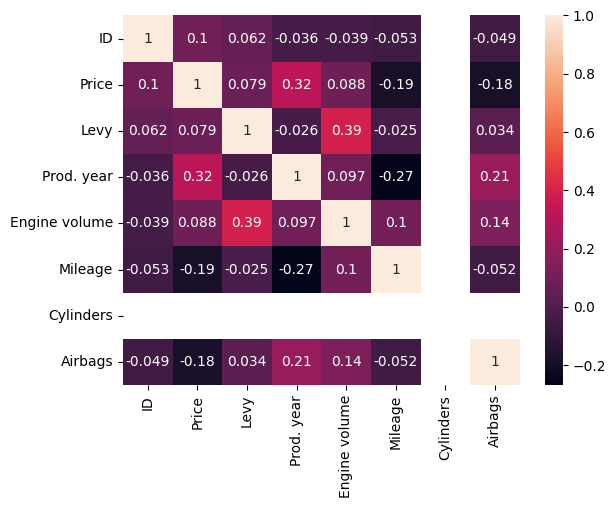

In [385]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

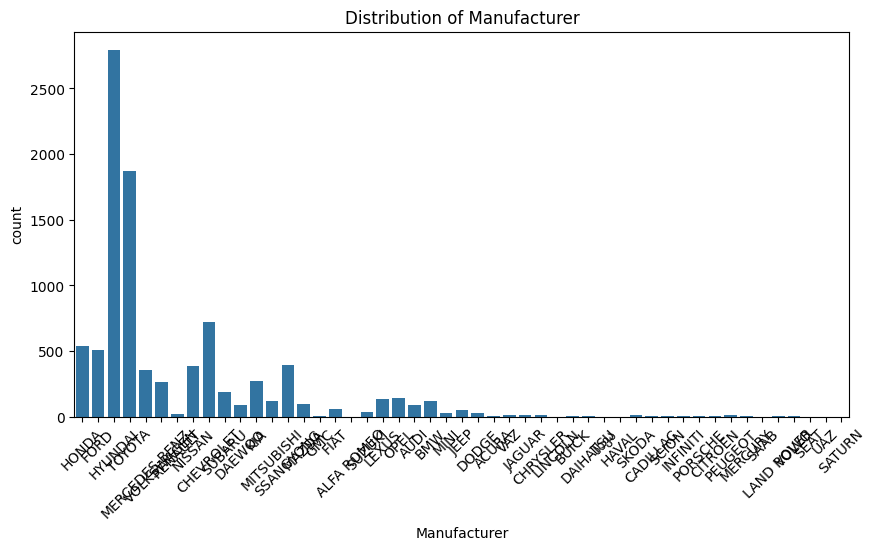

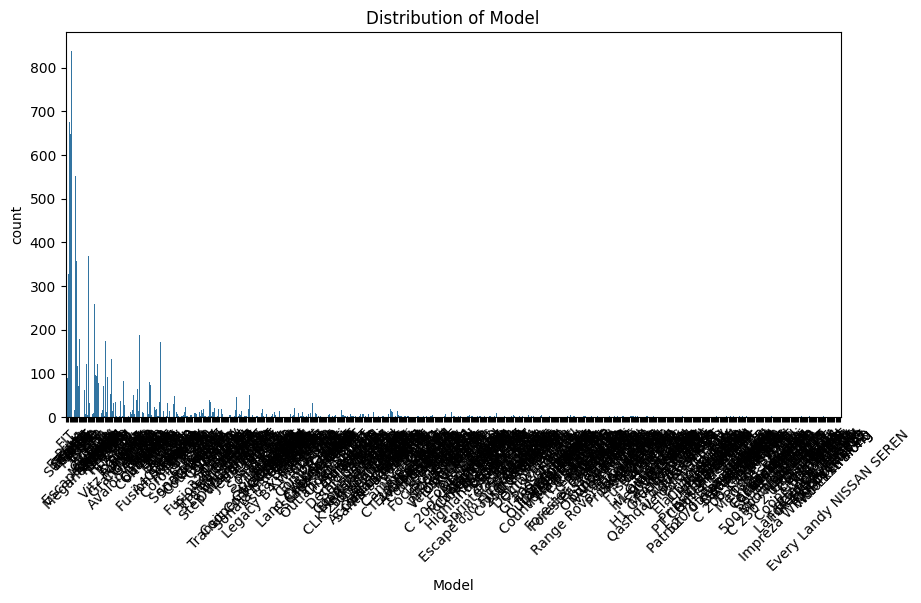

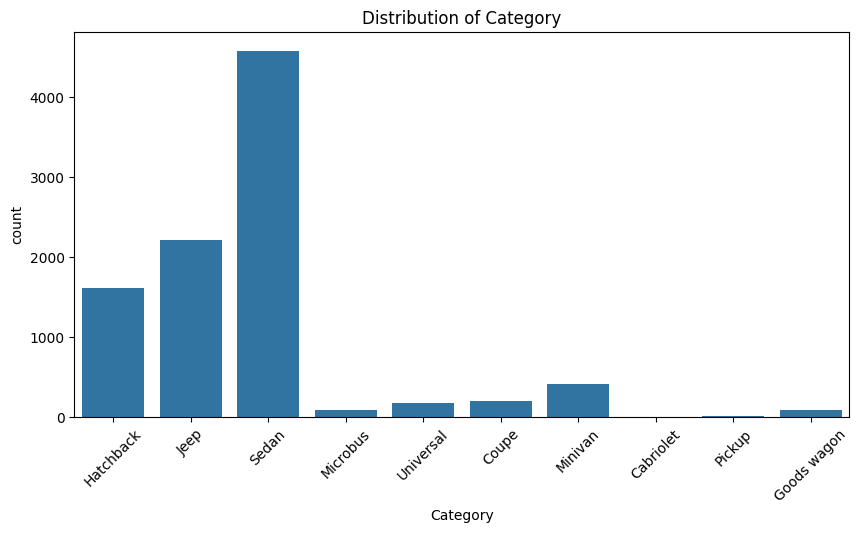

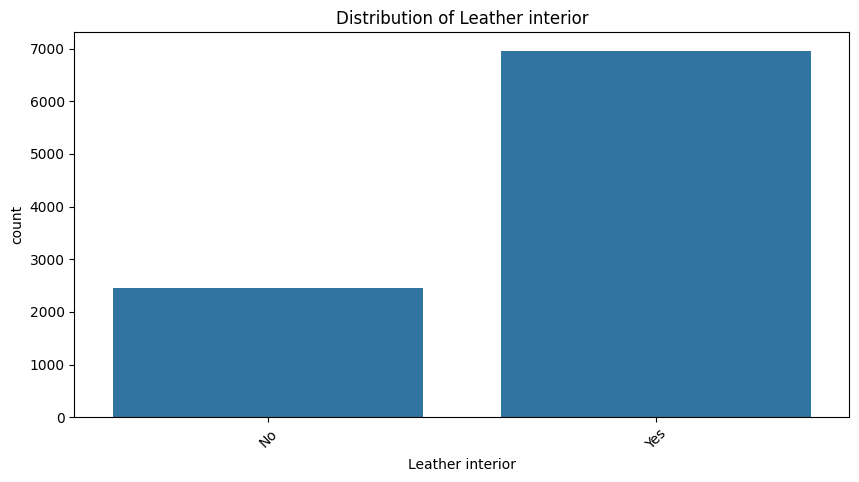

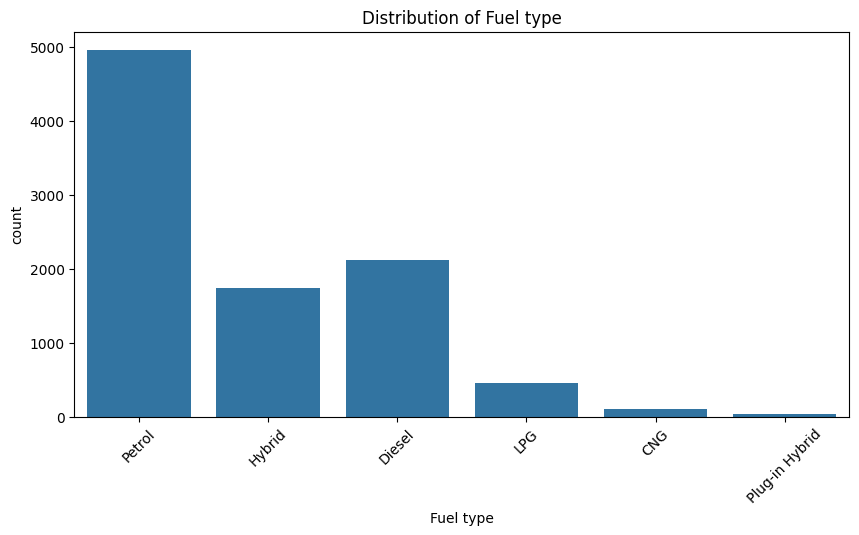

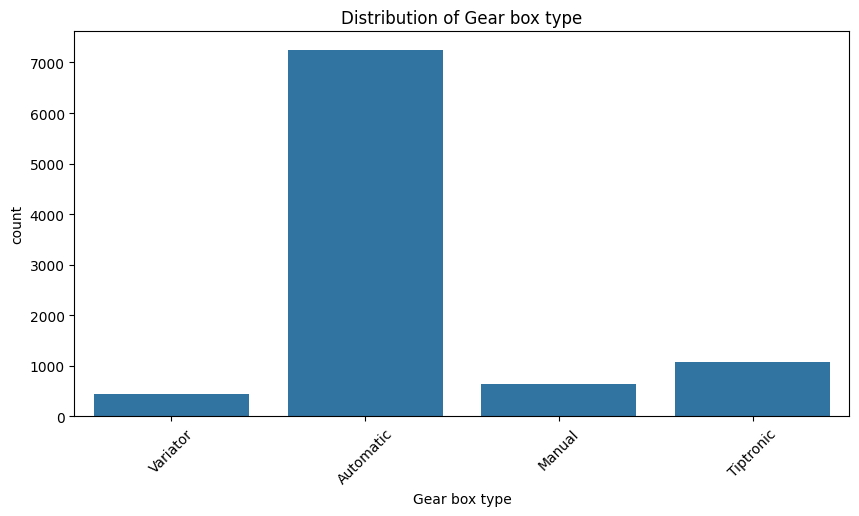

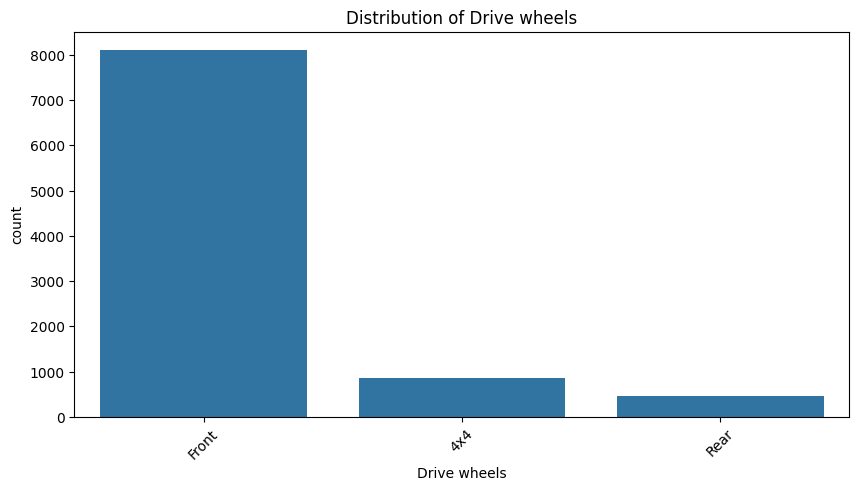

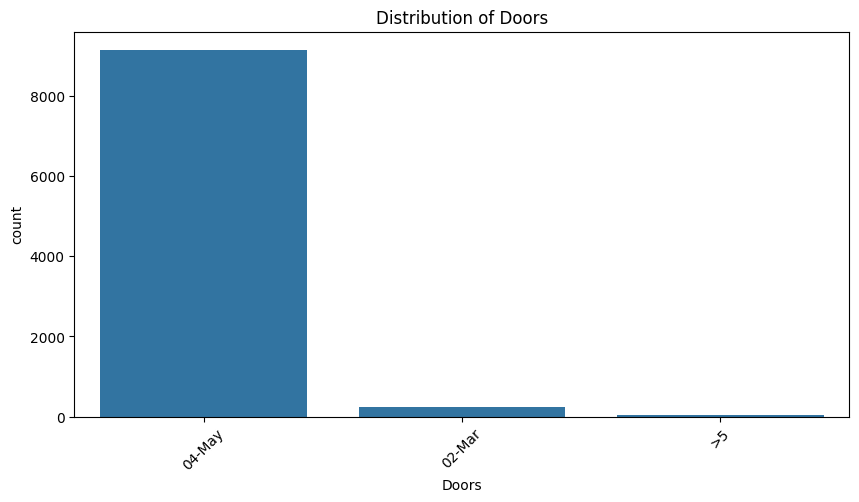

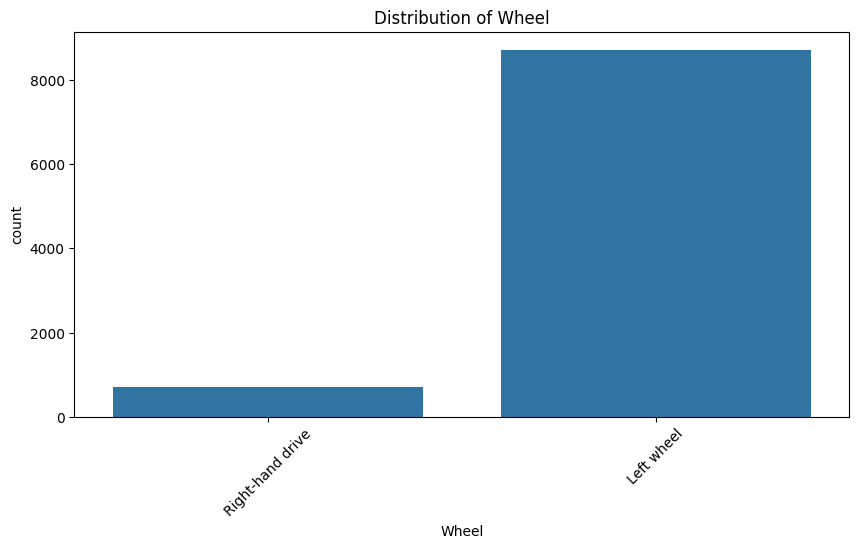

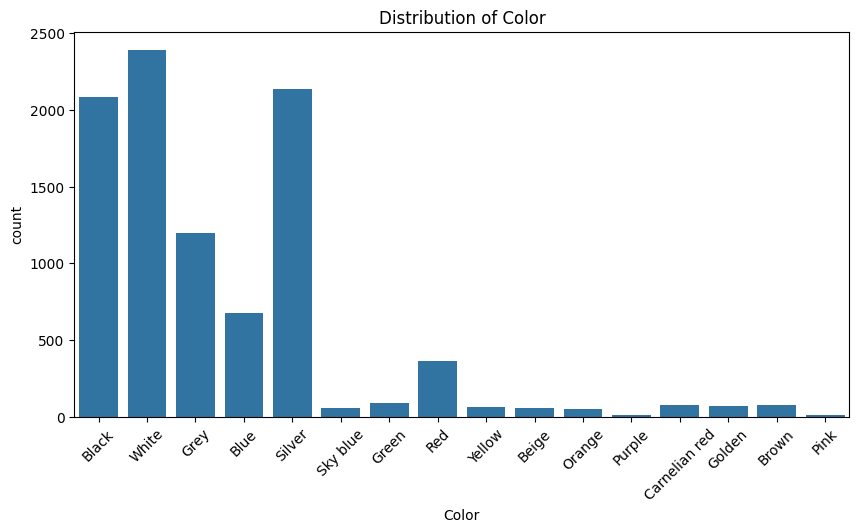

In [386]:
for i in categorical_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=i)
    plt.title(f"Distribution of {i}")
    plt.xticks(rotation=45)
    plt.show()

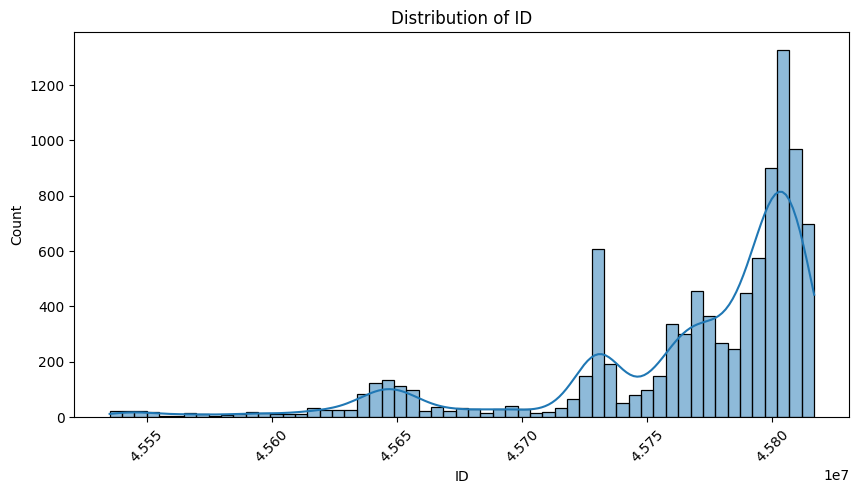

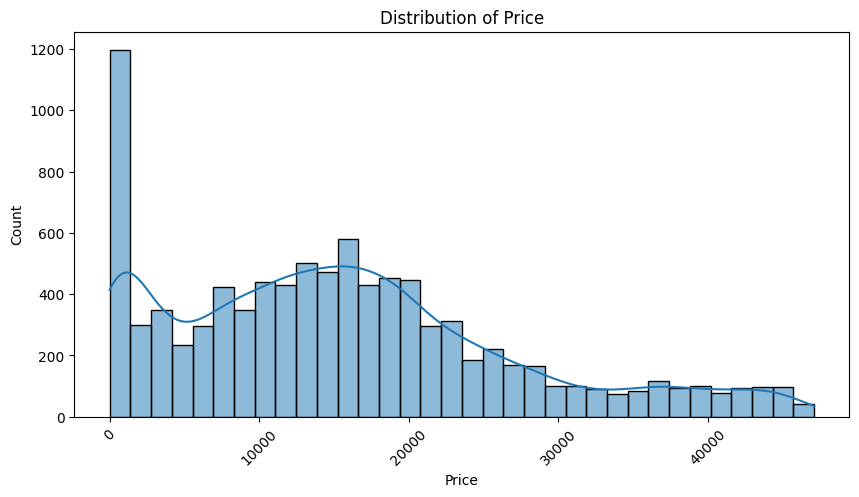

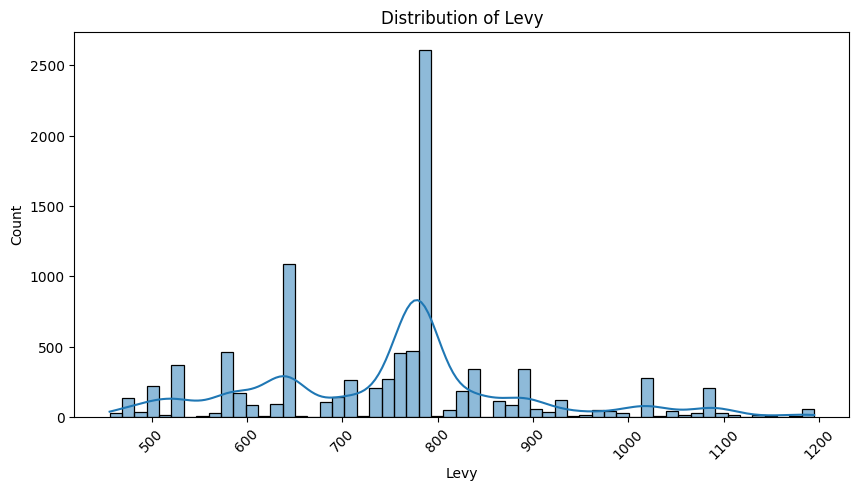

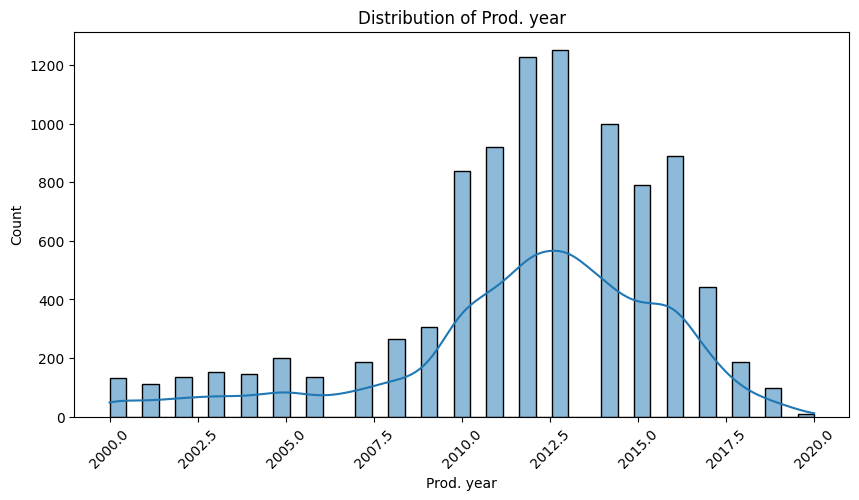

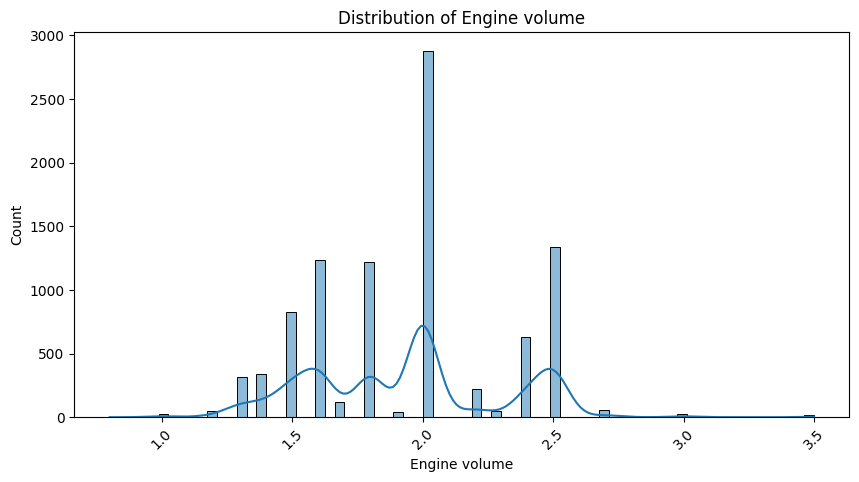

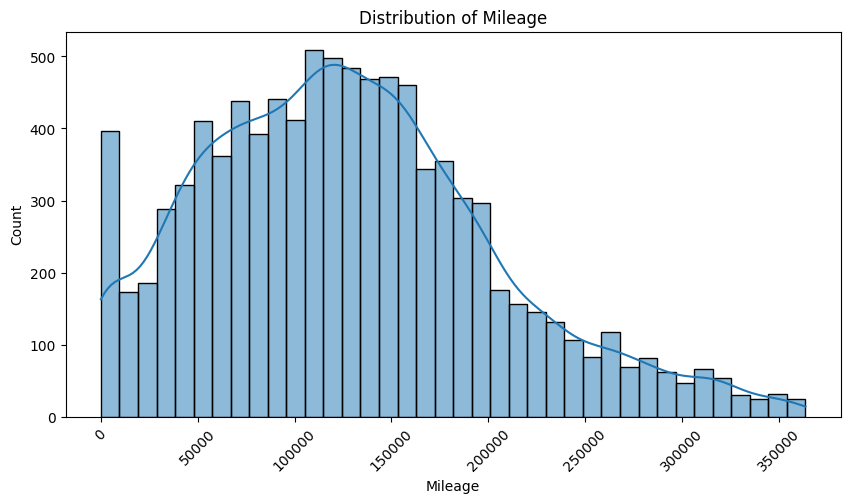

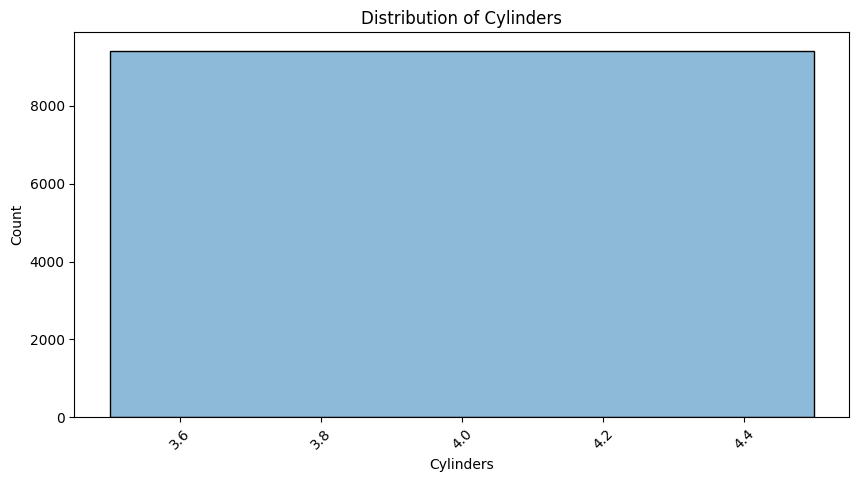

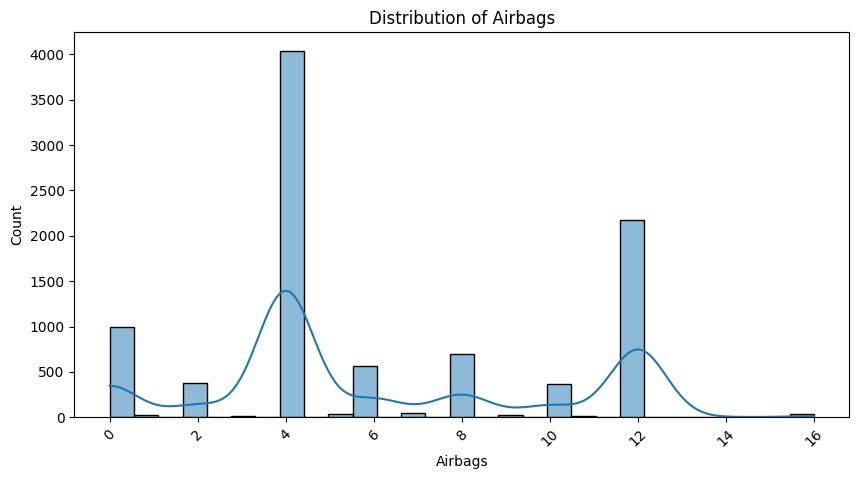

In [387]:
for i in numerical_columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x=i, kde=True)
    plt.title(f"Distribution of {i}")
    plt.xticks(rotation=45)
    plt.show()

In [388]:
df.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')

In [389]:
X = df.drop(columns=["Price", "Model", "ID", "Mileage"])
y = df["Price"]

In [390]:
X.shape, y.shape

((9420, 14), (9420,))

In [391]:
x_categorical = X.select_dtypes(include=['object']).columns
x_numerical = X.select_dtypes(include=['number', 'int', 'float']).columns

print(f"Length of {len(x_categorical)} Categorical columns: {x_categorical}")
print(f"Length of {len(x_numerical)} Numerical columns: {x_numerical}")

Length of 9 Categorical columns: Index(['Manufacturer', 'Category', 'Leather interior', 'Fuel type',
       'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color'],
      dtype='str')
Length of 5 Numerical columns: Index(['Levy', 'Prod. year', 'Engine volume', 'Cylinders', 'Airbags'], dtype='str')


### Model Training

In [392]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer

In [393]:
num_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)

In [394]:
cat_transformer = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onhot', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]
)

In [395]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, x_numerical),
    ('cat', cat_transformer, x_categorical)
])

In [396]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7536, 14), (1884, 14), (7536,), (1884,))

In [397]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [398]:
model = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "XGBoost Regressor": XGBRegressor(random_state=42, eval_metric='rmse'),
    "CatBoost Regressor": CatBoostRegressor(random_state=42, verbose=0)
}

model_list = []
r2_list = []

for name, model in model.items():
    model.fit(X_train_preprocessed, y_train)

    y_train_pred = model.predict(X_train_preprocessed)
    y_pred = model.predict(X_test_preprocessed)

    r2 = r2_score(y_test, y_pred)
    model_list.append(name)
    r2_list.append(r2)

    print("Training Set")
    print(f"{name} R2 Score: {r2:.4f}")
    rmse_train = root_mean_squared_error(y_train, y_train_pred)
    print(f"{name} RMSE: {rmse_train:.4f}")
    print("Test Set")
    print(f"{name} R2 Score: {r2:.4f}")
    rmse_test = root_mean_squared_error(y_test, y_pred)
    print(f"{name} RMSE: {rmse_test:.4f}")
    print("-" * 30)
    

Training Set
Linear Regression R2 Score: 0.4788
Linear Regression RMSE: 8285.3229
Test Set
Linear Regression R2 Score: 0.4788
Linear Regression RMSE: 8211.2664
------------------------------
Training Set
Ridge Regression R2 Score: 0.4786
Ridge Regression RMSE: 8287.7922
Test Set
Ridge Regression R2 Score: 0.4786
Ridge Regression RMSE: 8212.8123
------------------------------
Training Set
Lasso Regression R2 Score: 0.4768
Lasso Regression RMSE: 8290.2576
Test Set
Lasso Regression R2 Score: 0.4768
Lasso Regression RMSE: 8227.1890
------------------------------
Training Set
Random Forest Regressor R2 Score: 0.7807
Random Forest Regressor RMSE: 3037.3236
Test Set
Random Forest Regressor R2 Score: 0.7807
Random Forest Regressor RMSE: 5326.3975
------------------------------
Training Set
Gradient Boosting Regressor R2 Score: 0.7141
Gradient Boosting Regressor RMSE: 6016.2965
Test Set
Gradient Boosting Regressor R2 Score: 0.7141
Gradient Boosting Regressor RMSE: 6081.9309
--------------------

In [399]:
df_results = pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model', 'R2 Score']).sort_values(by='R2 Score', ascending=False)
df_results

,Model,R2 Score
8,CatBoost Regressor,0.790893
7,XGBoost Regressor,0.781646
3,Random Forest Regressor,0.780702
4,Gradient Boosting Regressor,0.714076
6,K-Neighbors Regressor,0.684682
5,Decision Tree Regressor,0.655302
0,Linear Regression,0.478820
1,Ridge Regression,0.478623
2,Lasso Regression,0.476797


### Model Tuniing

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score


def objective(trial):
    model_name = trial.suggest_categorical(
        "model", ["catboost", "xgboost", "random_forest"]
    )

    if model_name == "catboost":
        model = CatBoostRegressor(
            depth=trial.suggest_int("cb_depth", 4, 10),
            learning_rate=trial.suggest_float("cb_lr", 0.01, 0.04),
            iterations=trial.suggest_int("cb_iterations", 300, 600),
            bagging_temperature=trial.suggest_float("cb_bagging_temperature", 0, 1),
            verbose=0,  # 🔇 important (catboost prints a lot)
            random_state=42
        )

    elif model_name == "xgboost":
        model = XGBRegressor(
            max_depth=trial.suggest_int("xgb_max_depth", 4, 10),
            learning_rate=trial.suggest_float("xgb_lr", 0.01, 0.04),
            n_estimators=trial.suggest_int("xgb_n_estimators", 300, 600),
            random_state=42,
            eval_metric='rmse'
        )

    else:
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("rf_n_estimators", 100, 500),
            max_depth=trial.suggest_int("rf_max_depth", 4, 10),
            min_samples_split=trial.suggest_int("rf_min_samples_split", 2, 10),
            min_samples_leaf=trial.suggest_int("rf_min_samples_leaf", 1, 4),
            random_state=42
        )

    score = cross_val_score(model, X_train_preprocessed, y_train, cv=5, scoring="r2").mean()
    return score

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, n_jobs=-1)



# Best result
print("Best model + params:", study.best_params)
print("Best score:", study.best_value)

Best model + params: {'model': 'xgboost', 'xgb_max_depth': 8, 'xgb_lr': 0.035551635338764084, 'xgb_n_estimators': 528}
Best score: 0.7778872847557068
------------------------------------------------------------------------------------------------------------------------
